## https://timm.fast.ai/SGDR  
It's Similar to torch.optim.lr_schedulers OneCycleLR but Timm's implementation feels more manageble still Timm docs are bit outdated for implementation So I provide the things I understood Below.

In [1]:
from timm.scheduler.cosine_lr import CosineLRScheduler
import torch
import matplotlib.pyplot as plt

/home/mdi220/.virtualenvs/tvsb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EPOCHS = 200

In [3]:
import timm
print(timm.__version__)

0.9.16


In [4]:
model = torch.nn.Linear(3,3)

In [7]:
x = []
y = []
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
scheduler = CosineLRScheduler(optimizer, t_initial=EPOCHS, lr_min=2e-8,
                  cycle_mul=1.0, cycle_decay=1.0, cycle_limit=1,
                  warmup_t=10, warmup_lr_init=1e-6, warmup_prefix=False, t_in_epochs=True,
                  noise_range_t=None, noise_pct=0.67, noise_std=1.0,
                  noise_seed=42, k_decay=1.0, initialize=True)

## Training Configuration
- `t_initial`: EPOCHS
    - How much you want to Run the Scheduler, incase of cyclic it will be multiple "t_initial" when cycle_limit>1.
- `lr_min`: 2e-8
  - This value ensures that the Learning Rate (LR) will not be set lower than 2e-8.

- `warmup_t`: Warmup Time
  - This indicates a warm-up period of 10 epochs during training.

## Why Warm Up Instead of Direct Training?

Warming up is analogous to preparing before engaging in sports training or hitting the gym. Similarly, during the training of large models, there's a practice of gradually warming up the learning rate (LR) at the beginning and then reducing it later.

- `warmup_lr_init`: Initial LR for Warm-up
  - The LR for warm-up will start at the value specified by `warmup_lr_init` and will linearly increase until it reaches the optimizer's main LR value.


In [8]:

for epoch in range(EPOCHS):
    y.append((optimizer.param_groups[0]['lr']))
    x.append(epoch)
    scheduler.step(epoch)

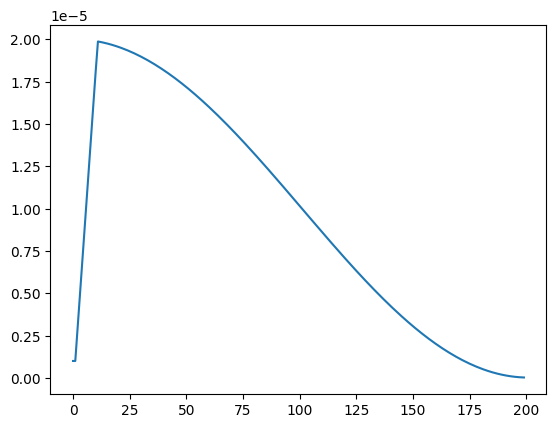

In [9]:
plt.plot(x,y)

## Cyclic Configuration

- `cycle_mul`: 2.0
    - Determines the length of the next cycle, which will be '2.0' times the length of the previous cycle in terms of epochs.

- `cycle_decay`: 0.5
  - As illustrated in the example below, the LR of the first cycle is set at 2e-5. For the subsequent cycle, the LR is reduced by a factor of '0.5', resulting in a LR of 1e-5.

- `cycle_limit`: 5
  - A value of '1' signifies the use of the OneCycleLR strategy. The parameter 'cycle_limit' restricts the number of cycles. For instance, if 't_initial=20' and the total EPOCHS=100, with 'cycle_mul=1.0', a total of 5 cycles will be executed.


In [8]:
x = []
y = []
optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)
scheduler = CosineLRScheduler(optimizer, t_initial=20, lr_min=2e-8,
                  cycle_mul=2.0, cycle_decay=.5, cycle_limit=5,
                  warmup_t=10, warmup_lr_init=1e-6, warmup_prefix=False, t_in_epochs=True,
                  noise_range_t=None, noise_pct=0.67, noise_std=1.0,
                  noise_seed=42, k_decay=1.0, initialize=True)

In [9]:
for epoch in range(EPOCHS):
    y.append((optimizer.param_groups[0]['lr']))
    x.append(epoch)
    scheduler.step(epoch)

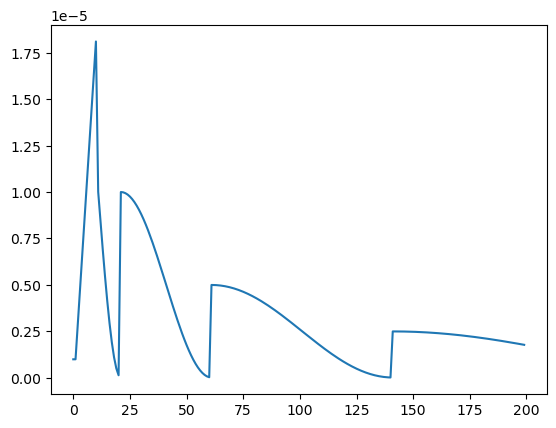

In [10]:
plt.plot(x,y)